In [1]:
#!pip install squarenet

In [2]:
from squarenet import SquareNet
from squarenet.sampler import samplepoints
from squarenet.utils import to_backend

**Native Support:** `sn.fit(x)` natively accepts and processes PyTorch tensors, JAX arrays, and NumPy arrays.

The real power of JAX and PyTorch comes alive on a **GPU** ⚡, or when one realy need to avoid conversion to numpy.

🎯 Any of following fonction natively support sn specified backend at the init (sn = SquareNet(..., backend = numpy/jax/torch)):

`sn.map(x)`
`sn.invert_map(grid_x)`
`sn.mapidx(id)`
`sn.invert_mapidx(grid_id)`

On **CPU**, NumPy can be faster than JAX or PyTorch for the sorting/fitting phase due to lower framework overhead.

Thus  always consider to fit on a numpy array (call sn.fit(... fit_with_numpy = True)), \
then just for the life time of the fit every object involved will be numpy arrays on the cpu, \
and converted back at the end.

## Backend + Device selection

In [ ]:
device = "cpu"

In [2]:
backend = "jax"

In [25]:
backend = "torch"

In [ ]:
if backend == "torch":
    import torch
if backend == "jax":
    import jax
    import jax.numpy as jnp

## ❒ SquareNet for PyTorch

I. sample a dataset \
as a torch tensor, on the device of your choice

In [27]:
I = 100
N = I*I*I
points = samplepoints("ball", size = (N, 3))
points = to_backend(points, backend = "torch", device = device)

type(points)

torch.Tensor

II. Specify backend to the SquareNet

In [28]:
sn = SquareNet(gridshape = (I, I, I), backend = "torch", device = device)
sn.fit(points, fit_with_numpy = False) #consider trying with fit_with_numpy = True

Starting gridification... available method [fast, robust, ultimate]
selected fast

=== Carthesian sort ===
(max iter: 1000)
torch working (fast) ...

=== Final Status ===
succesfully sorted at iteration 1


In [10]:
grided_points = sn.map(points)
type(grided_points)

torch.Tensor

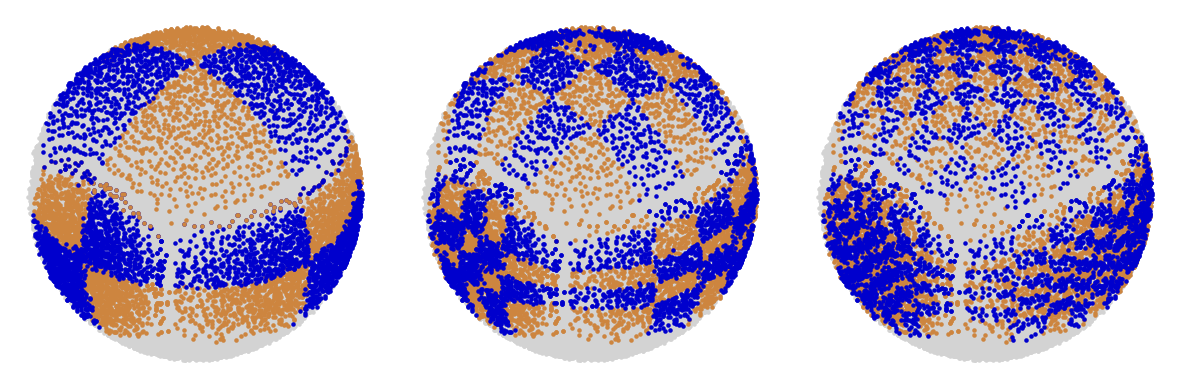

(<Figure size 1200x400 with 3 Axes>, None)

In [10]:
sn.plot(save = False)

## ❒ SquareNet for Jax

In [23]:
I = 100
N = I*I
points = samplepoints("spiky", size = (N, 2))
points = to_backend(points, backend = "jax")

type(points)

jaxlib._jax.ArrayImpl

sn.fit might be slow ⌛ at the first jax execution but faster after that.

In [ ]:
sn = SquareNet(gridshape = (I, I), backend = "jax")
sn.fit(points, method = "ultimate", fit_with_numpy = False) #consider trying with fit_with_numpy = True

Starting gridification... available method [fast, robust, ultimate]
selected ultimate

=== Carthesian sort ===
(max iter: 2 x 1000 + 4 x 1000 + 1000)
jax working (ultimate) ...

=== Final Status ===
succesfully sorted at iteration 3002


In [13]:
grided_points = sn.map(points)
type(grided_points)

jaxlib._jax.ArrayImpl

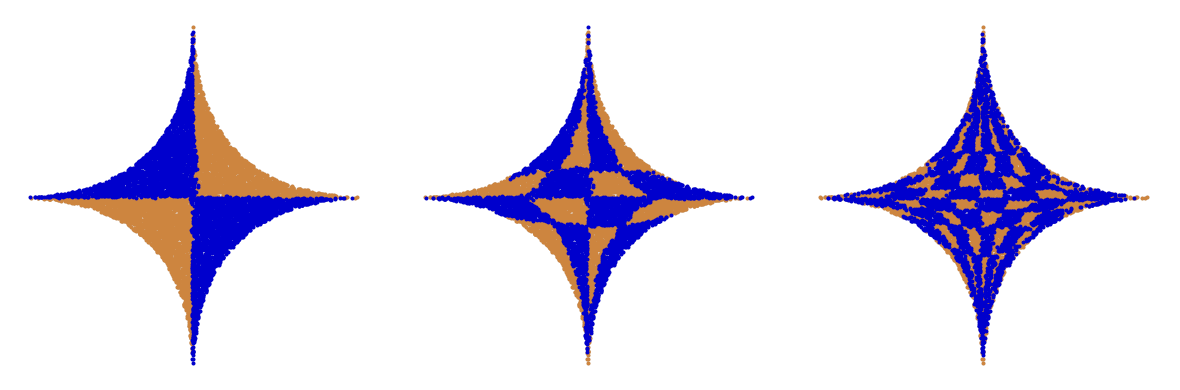

(<Figure size 1200x400 with 3 Axes>, None)

In [9]:
sn.plot(save = False)